In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


In [8]:
# Loading Dataset
mnist = tf.keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [9]:
# Checking Shapes
print(x_train.shape)
print(y_train.shape)
print()
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)

(10000, 28, 28)
(10000,)


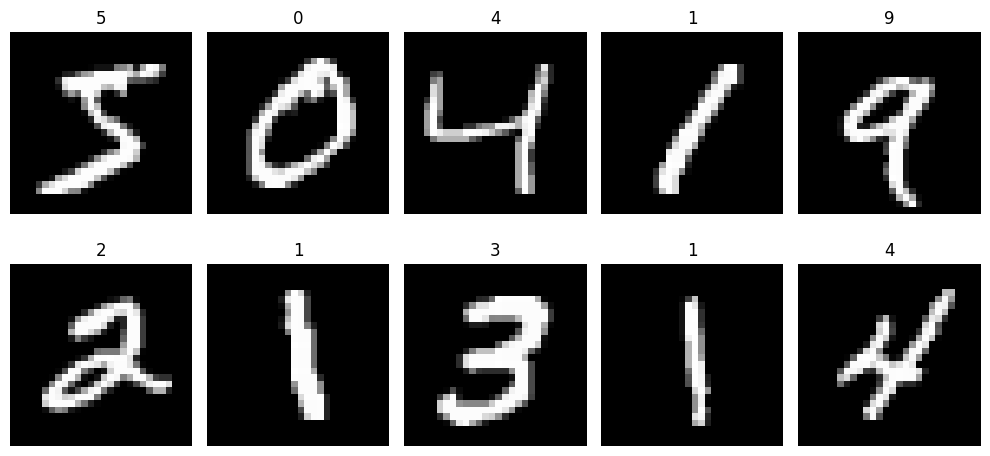

In [10]:
# Display Images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i],cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()

plt.show()

In [11]:
# Checking Pixel Values
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [12]:
# Checking Classes
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [13]:
# Creating Validation Dataset
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,test_size=0.2,random_state=42)

Preprocessing

In [14]:
# data shapes
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(48000, 28, 28)
(12000, 28, 28)
(10000, 28, 28)


In [15]:
# Normalization
x_train = x_train/255.0
x_val = x_val/255.0
x_test = x_test/255.0

In [16]:
# Reshaping
x_train = x_train.reshape(-1,28,28,1)
x_val = x_val.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [17]:
# Checking Shapes after reshaping
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(48000, 28, 28, 1)
(12000, 28, 28, 1)
(10000, 28, 28, 1)


In [18]:
# Checking Pixel Values
print(x_train[0].max())
print(x_train[0].min())

1.0
0.0


CNN Architecture Design

In [19]:
# Building the CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import(Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

In [20]:
model=Sequential()

In [21]:
# first convolution layer
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        padding='same',
        input_shape=(28,28,1),
        activation='relu'
    )
)

C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# First Pooling Layer
model.add(
    MaxPooling2D(
               (2,2)
    )
)

In [23]:
# second convolution layer
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding='same',
        input_shape=(28,28,1),
        activation='relu'
    )
)

In [24]:
# second Pooling Layer
model.add(
    MaxPooling2D(
               (2,2)
    )
)

In [25]:
# flatten layer
model.add(
            Flatten()
)

In [26]:
# Dense layer
model.add(
        Dense(
                128,
                activation="relu"
        )
)

In [27]:
# Droupout layer
model.add(
            Dropout(
                    0.5
            )
)

In [28]:
# output layer
model.add(
        Dense(
                10,
                activation="softmax"
        )
)

In [29]:
# alternative code:

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import(
#         Conv2D,
#         MaxPooling2D,
#         Flatten,
#         Dense,
#         Dropout
# )

# model = Sequential([

#         Conv2D(
#                 32,
#                 (3,3),
#                 activation="relu",
#                 padding="same",
#                 input_shape=(28,28,1)
#         ),

#         MaxPooling2D((2,2)),

#         Conv2D(
#                 64,
#                 (3,3),
#                 activation="relu",
#                 padding="same"
#         ),

#         MaxPooling2D((2,2)),

#         Flatten(),

#         Dense(
#                 128,
#                 activation="relu"
#         ),

#         Dropout(0.5),

#         Dense(
#                 10,
#                 activation="softmax"
#         )

# ])

Training Design

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compile the Model
model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
)

In [32]:
# Early stopping
from tensorflow.keras.callbacks import EarlyStopping

In [33]:
early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
)

In [34]:
# Model Checkpoint
from tensorflow.keras.callbacks import ModelCheckpoint

In [35]:
checkpoint = ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
)

Training & Model Analysis

In [36]:
# Training the CNN
history = model.fit(
            x_train,
            y_train,

            validation_data=(x_val,y_val),

            epochs=50,

            batch_size=32,

            callbacks=[early_stop,checkpoint]
)

Epoch 1/50
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9338 - loss: 0.2164  
Epoch 1: val_accuracy improved from None to 0.98225, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9339 - loss: 0.2160 - val_accuracy: 0.9822 - val_loss: 0.0571
Epoch 2/50
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9761 - loss: 0.0827 
Epoch 2: val_accuracy improved from 0.98225 to 0.98700, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9761 - loss: 0.0828 - val_accuracy: 0.9870 - val_loss: 0.0418
Epoch 3/50
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9816 - loss: 0.0619  
Epoch 3: val_accuracy improved from 0.98700 to 0.98817, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9816 - loss

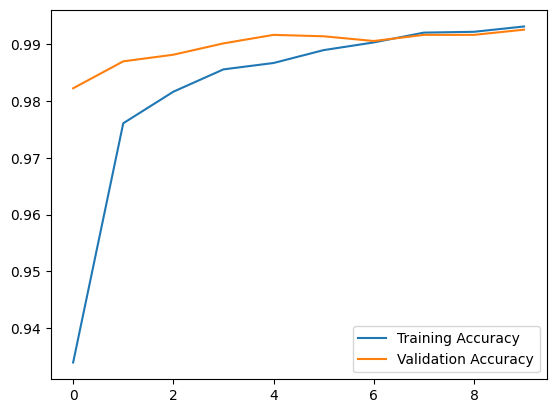

In [37]:
# Accuracy Curve
plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
)

plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
)

plt.legend()

plt.show()

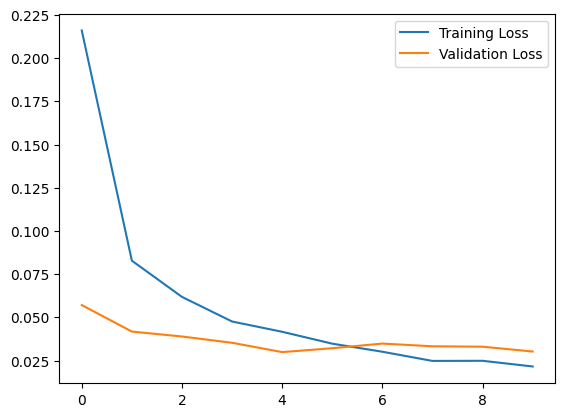

In [38]:
# Loss Curve
plt.plot(
        history.history["loss"],
        label="Training Loss"
)

plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
)

plt.legend()

plt.show()

Testing & Model Evaluation

In [39]:
# Evaluate the Model
loss,accuracy = model.evaluate(
                    x_test,
                    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0264   


In [40]:
print("Loss :",loss)
print("Accuracy :",accuracy)

Loss : 0.02641800232231617
Accuracy : 0.991599977016449


In [41]:
# Predictions
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


In [42]:
predictions[0]

array([2.1703728e-14, 3.5477990e-10, 1.3538326e-09, 6.7584516e-10,
       1.3212524e-10, 3.2312837e-12, 7.8115377e-17, 9.9999976e-01,
       1.5297000e-11, 1.8442489e-07], dtype=float32)

In [43]:
predictions.shape

(10000, 10)

In [44]:
# convert probabilities into predictions
y_pred = np.argmax(
            predictions,
            axis=1
)

In [45]:
y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [46]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

In [47]:
cm = confusion_matrix(y_test, y_pred)

In [48]:
cm

array([[ 976,    0,    0,    0,    0,    0,    2,    1,    1,    0],
       [   0, 1132,    0,    2,    0,    0,    0,    0,    1,    0],
       [   0,    0, 1026,    3,    0,    0,    0,    3,    0,    0],
       [   0,    0,    1, 1007,    0,    1,    0,    0,    1,    0],
       [   0,    0,    0,    0,  967,    0,    1,    0,    1,   13],
       [   0,    0,    0,    9,    0,  881,    1,    1,    0,    0],
       [   5,    1,    0,    1,    1,    4,  944,    0,    2,    0],
       [   0,    1,    5,    1,    0,    0,    0, 1016,    1,    4],
       [   2,    0,    2,    1,    0,    1,    0,    1,  966,    1],
       [   0,    0,    0,    2,    2,    1,    0,    1,    2, 1001]])

In [49]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [50]:
# Misclassified Images
misclassified = np.where(y_pred != y_test)[0]

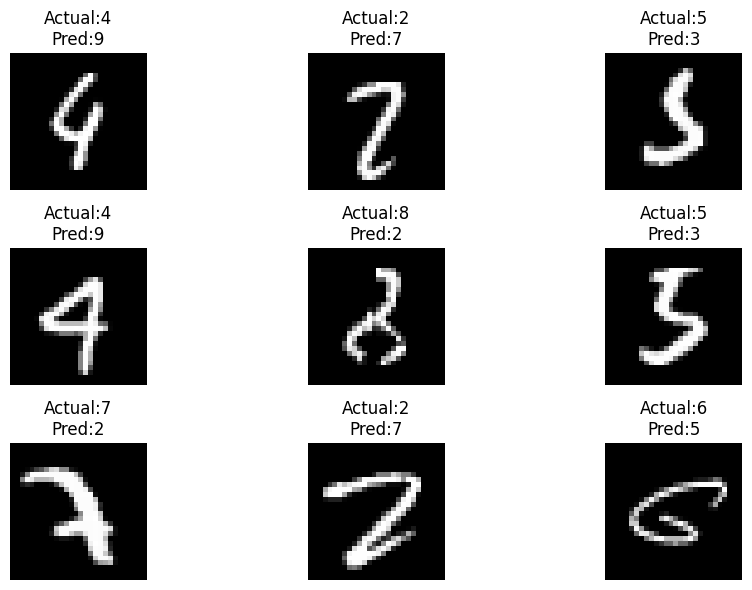

In [51]:
plt.figure(figsize=(10,6))

for i in range(9):

    plt.subplot(3,3,i+1)

    index = misclassified[i]

    plt.imshow(

            x_test[index].reshape(28,28),

            cmap="gray"

            )


    plt.title(

f"Actual:{y_test[index]}\nPred:{y_pred[index]}"

            )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [52]:
# model saving
model.save("Digit_CNN.keras")

In [53]:
# loading model
from tensorflow.keras.models import load_model
model = load_model("Digit_CNN.keras")

Building a Prediction Pipeline.

In [55]:
import cv2
print(cv2.__version__)

5.0.0


In [105]:
# Reading Images
image = cv2.imread("digit-2.jpg")

In [106]:
print(image.shape)

(339, 338, 3)


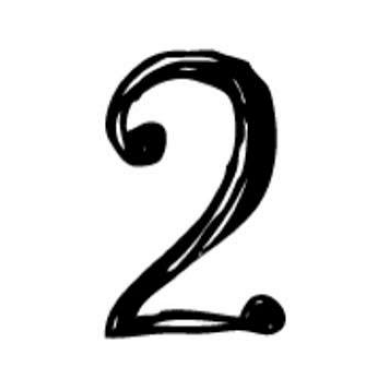

In [107]:
# Visualization
plt.imshow(image)
plt.axis('off')
plt.show()

In [108]:
# Converting into Grayscale
gray = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY
)

In [109]:
print(gray.shape)

(339, 338)


In [110]:
# Resize Image
gray = cv2.resize(
            gray,
            (28,28)
)

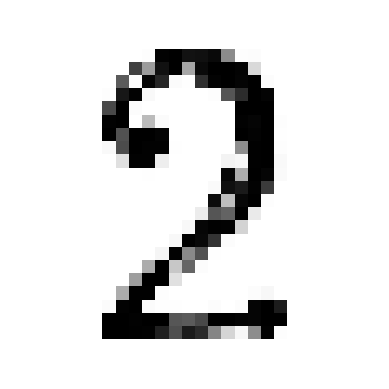

In [111]:
plt.imshow(
        gray,
        cmap="gray"
)
plt.axis('off')
plt.show()

In [112]:
# Normalization
x_train=x_train/255.0
gray = gray/255.0

In [113]:
# Reshape: Why 1? --> ONE IMAGE
gray = gray.reshape(1,28,28,1)

In [114]:
# prediction
prediction = model.predict(gray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [115]:
# Final Digit
digit = np.argmax(prediction)
print("Predicted Digit :",digit)

Predicted Digit : 2
